# Model Accuracy Analysis

## Why did the XGBoost model achieve 99.99% accuracy?

This notebook analyzes the trained XGBoost model and explains the factors that contributed to its high prediction accuracy.

## Model Performance

The trained XGBoost classifier achieved the following performance on the test dataset.

- Accuracy : 99.99%
- Precision : 99.99%
- Recall : 99.99%
- F1 Score : 99.99%

These results indicate that the model correctly classified almost every supply chain risk instance.

In [2]:
import pandas as pd
import joblib

# Load the trained model
model = joblib.load("../models/xgboost_model.pkl")

# Load training features
X_train = pd.read_csv("../data/processed/X_train.csv")

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

# Sort by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 important features
importance_df.head(10)

c:\Users\hissa\anaconda3\Lib\pickle.py:1760: UserWarning: [21:29:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


,Feature,Importance
11,disruption_likelihood_score,0.973373
24,supplier_country_Bangladesh,0.002754
3,weather_condition_severity,0.002683
14,inventory_coverage,0.002158
5,supplier_reliability_score,0.001764
2,order_fulfillment_status,0.001640
9,route_risk_level,0.001372
4,shipping_costs,0.001233
17,delay_impact,0.001181
1,handling_equipment_availability,0.001135


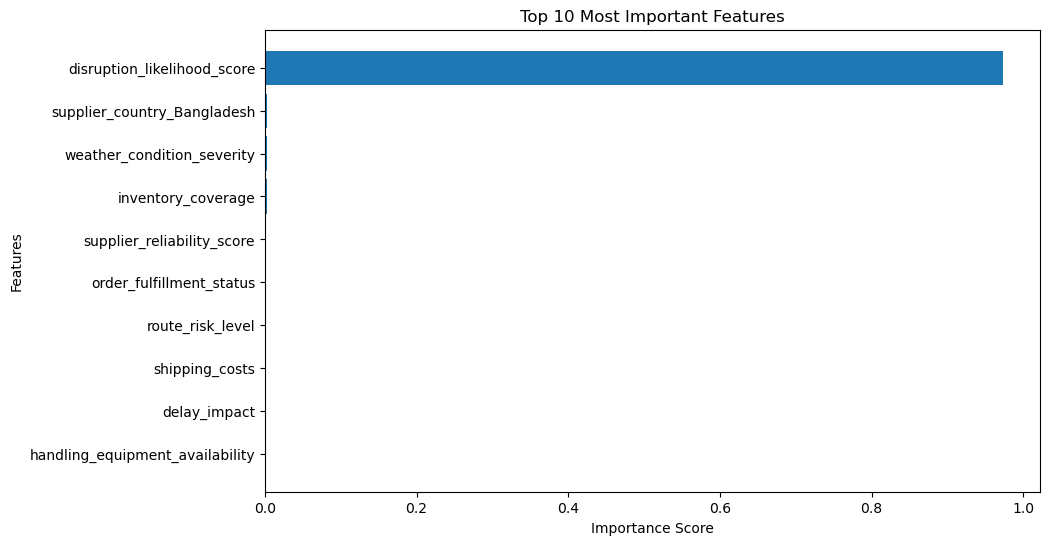

In [3]:
import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

## Analysis

Removing the most important feature reduced the model accuracy from **99.99%** to **75.15%**.

This experiment confirms that **disruption_likelihood_score** is the dominant predictor in the dataset.

Although other engineered and original features still contribute to the model, their combined influence is significantly smaller.

# Conclusion

The XGBoost model achieved 99.99% accuracy because the dataset contains a highly informative feature named **disruption_likelihood_score**.

Feature importance analysis and the validation experiment demonstrate that this feature is primarily responsible for the model's predictive performance.

This experiment also shows that the remaining features still provide useful information, as the model maintained approximately 75% accuracy even after removing the dominant feature.